In [35]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from natsort import natsorted
import re


In [36]:
example_output = '../../../../data/bamfeatures/testoutput/out.tsv'

In [37]:
length_input = '../../../../data/gtf/Saccharomyces_cerevisiae.R64-1-1.75.lengths'

In [38]:
# length_input = '../../../../data/gtf/Homo_sapiens.GRCh37.75.lengths'

In [39]:
df = pd.read_csv(length_input, sep='\t')
length_dict = df.set_index(df.columns[0]).T.to_dict()

In [40]:
def add_to_pcr_index(pcr_index_count, pcr_index):
    if pcr_index in pcr_index_count:
        pcr_index_count[pcr_index] += 1
    else:
        pcr_index_count[pcr_index] = 1

In [41]:
def add_to_gene_dict(gene_dict, gene_id, pcr_index):
    if gene_id in gene_dict:
        gene_dict[gene_id] = (gene_dict[gene_id][0] + 1, gene_dict[gene_id][1] + (1 if pcr_index == '0' else 0))
    else:
        gene_dict[gene_id] = (1, 1 if pcr_index == '0' else 0)

In [42]:
# Open example_output line by line
genic_count = 0
split_inconsistent_count = 0
gdist_count = 0
transcriptomic_count = 0
merged_transcriptomic_count = 0
intronic_count = 0
gene_dict = {}
pcr_index_count = {}

# TODO Biotype count
with open(example_output, 'r') as file:
    for line in file:
        parts = line.strip().split("\t")
        if (parts[1][0] == 'm'):
            if parts[4][7] != '0':
                genic_count += 1
                # Now check whether it's transcriptomic, merged or intronic
                splitmatch = parts[5].split("|")
                for matching_gene in splitmatch:
                    matching_gene_parts = matching_gene.split(":")
                    gene_id = matching_gene_parts[0].split(",")[0]
                    pcr_index=parts[6].split(" ")[1]
                    add_to_pcr_index(pcr_index_count,pcr_index)
                    add_to_gene_dict(gene_dict, gene_id,pcr_index)
                    if matching_gene_parts[1].startswith("MERGED"):
                        merged_transcriptomic_count+=1
                    elif matching_gene_parts[1].startswith("INTRONIC"):
                        intronic_count+=1
                    else:
                        transcriptomic_count+=1

        else:
            gdist_count += 1
    else:
        split_inconsistent_count += 1

In [43]:
def calc_rpkm(num_reads, total_genes_matched, gene_length):
    return (num_reads*1_000*1_000_000.0)/(total_genes_matched*gene_length)

In [44]:
rows = []

# Iterate through the gene_dict
for gene_id, vals in gene_dict.items():
    length = length_dict[gene_id]["length"]
    chr = length_dict[gene_id]["chromosome"]
    total_rpkm = calc_rpkm(vals[0], genic_count, length)
    unique_rpkm = calc_rpkm(vals[1], genic_count, length)

    # Append a dictionary to the list
    rows.append({
        'chromosome': chr,
        'gene_id': gene_id,
        'total_rpkm': total_rpkm,
        'unique_rpkm': unique_rpkm
    })

# Create the DataFrame from the list of rows
rpkm_df = pd.DataFrame(rows, columns=['chromosome', 'gene_id', 'total_rpkm', 'unique_rpkm'])

In [45]:
rpkm_df

,chromosome,gene_id,total_rpkm,unique_rpkm
0,I,YAL069W,380.397001,380.397001
1,I,YAL068C,165.048286,165.048286
2,I,YAL063C,966.087622,966.087622
3,I,YAL062W,2703.476505,2659.872045
4,I,YAL061W,4921.044939,4921.044939
...,...,...,...,...
327,III,YCR003W,325.611564,325.611564
328,III,YCR005C,259.924198,259.924198
329,III,YCR008W,132.257236,132.257236
330,III,YCR011C,38.039700,38.039700


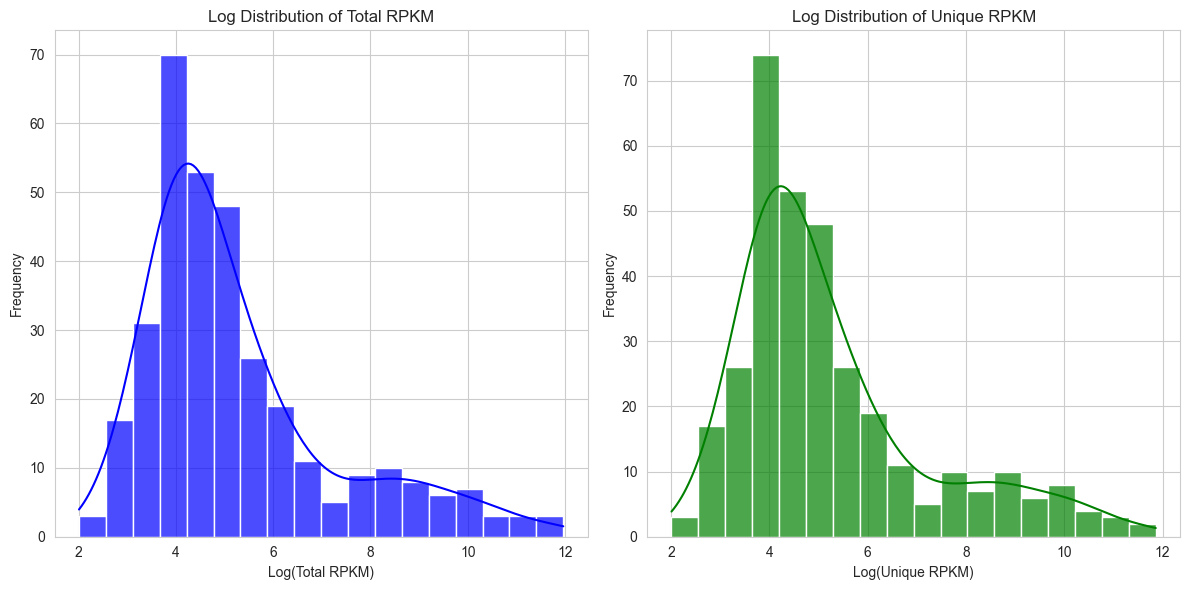

In [46]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Plot histogram and KDE for log(total_rpkm)
sns.histplot(np.log1p(rpkm_df['total_rpkm']), bins='auto', kde=True, ax=axes[0], color='blue', alpha=0.7)
axes[0].set_title('Log Distribution of Total RPKM')
axes[0].set_xlabel('Log(Total RPKM)')
axes[0].set_ylabel('Frequency')

# Plot histogram and KDE for log(unique_rpkm)
sns.histplot(np.log1p(rpkm_df['unique_rpkm']), bins='auto', kde=True, ax=axes[1], color='green', alpha=0.7)
axes[1].set_title('Log Distribution of Unique RPKM')
axes[1].set_xlabel('Log(Unique RPKM)')
axes[1].set_ylabel('Frequency')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [47]:
# fake_data = {
#     'chromosome': [str(i) for i in range(2, 24)],
#     'gene_id': [f'gene_{i}' for i in range(2, 24)],
#     'total_rpkm': np.random.rand(22) * 100,
#     'unique_rpkm': np.random.rand(22) * 100
# }
#
# fake_df = pd.DataFrame(fake_data)
#
# # Concatenate the fake data with the existing rpkm_df
# rpkm_df = pd.concat([rpkm_df, fake_df], ignore_index=True)

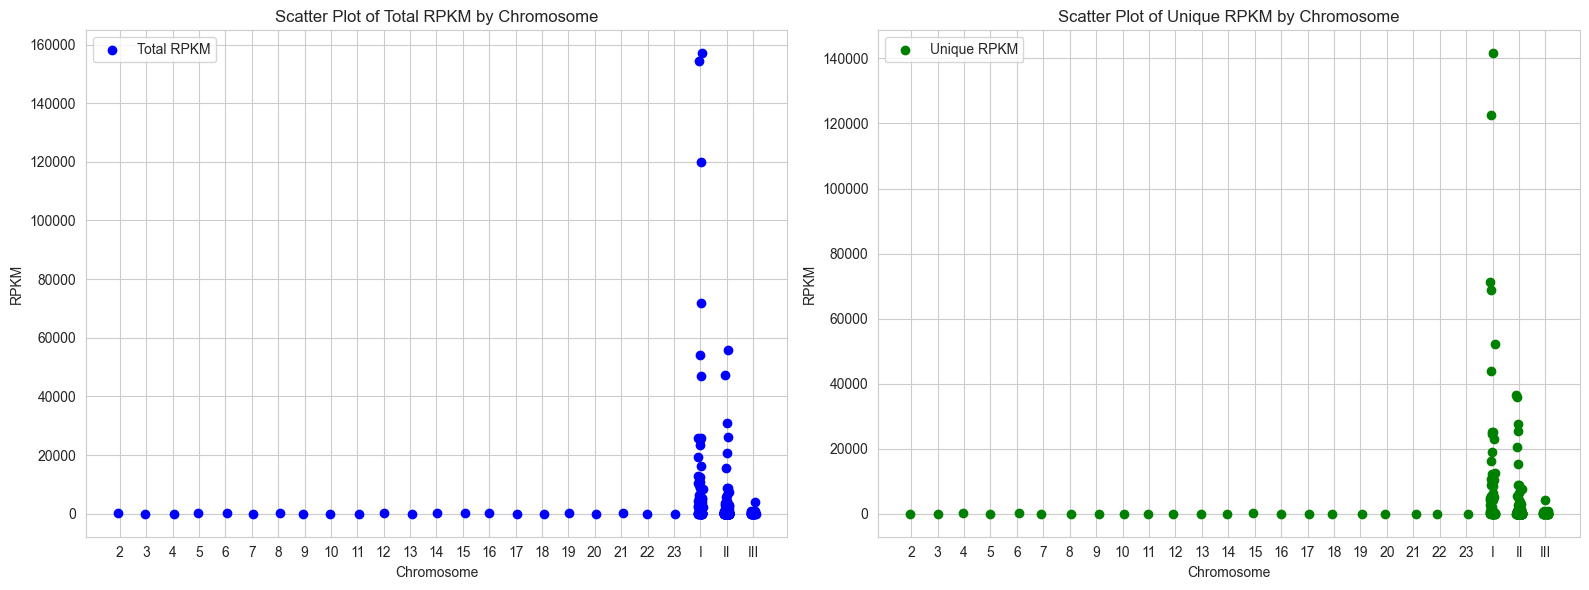

In [49]:
def roman_to_int(roman):
    """Convert Roman numeral to an integer."""
    roman_values = {
        'I': 1, 'V': 5, 'X': 10, 'L': 50, 'C': 100,
        'D': 500, 'M': 1000
    }
    prev_value = 0
    total = 0
    for char in reversed(roman):
        value = roman_values[char]
        if value < prev_value:
            total -= value
        else:
            total += value
        prev_value = value
    return total

def is_roman(s):
    """Check if a string is a valid Roman numeral."""
    roman_regex = re.compile(r'^(?=[MDCLXVI])M{0,4}(CM|CD|D?C{0,3})(XC|XL|L?X{0,3})(IX|IV|V?I{0,3})$')
    return bool(roman_regex.match(s))

def custom_key(chromosome):
    """Custom sorting key function."""
    if chromosome.isdigit():
        # Pure numeric chromosome
        return (0, int(chromosome))
    elif is_roman(chromosome):
        # Roman numeral chromosome
        return (1, roman_to_int(chromosome))
    else:
        # Alphabetical chromosome (e.g., X, Y)
        return (2, chromosome)

def custom_sort(chromosomes):
    """Sort a list of chromosome labels using the custom key."""
    return sorted(chromosomes, key=custom_key)
rpkm_df = rpkm_df.sort_values(
    by='chromosome',
    key=lambda col: col.map(custom_key)
)
# Create a new column for the x-axis positions
chromosomes = rpkm_df['chromosome'].unique()
x_positions = {chrom: i for i, chrom in enumerate(chromosomes)}
rpkm_df['x_pos'] = rpkm_df['chromosome'].map(x_positions)

# Add jitter to x positions to separate points within the same chromosome
jitter_width = 0.1
rpkm_df['x_pos_jitter_total'] = rpkm_df['x_pos'] + np.random.uniform(-jitter_width, jitter_width, size=len(rpkm_df))
rpkm_df['x_pos_jitter_unique'] = rpkm_df['x_pos'] + np.random.uniform(-jitter_width, jitter_width, size=len(rpkm_df))

# Create a figure with two subplots side by side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Plot scatter plot for total_rpkm
axes[0].scatter(rpkm_df['x_pos_jitter_total'], rpkm_df['total_rpkm'], color='blue', label='Total RPKM')
axes[0].set_title('Scatter Plot of Total RPKM by Chromosome')
axes[0].set_xlabel('Chromosome')
axes[0].set_ylabel('RPKM')
axes[0].set_xticks(ticks=range(len(chromosomes)))
axes[0].set_xticklabels(chromosomes)
axes[0].legend()

# Plot scatter plot for unique_rpkm
axes[1].scatter(rpkm_df['x_pos_jitter_unique'], rpkm_df['unique_rpkm'], color='green', label='Unique RPKM')
axes[1].set_title('Scatter Plot of Unique RPKM by Chromosome')
axes[1].set_xlabel('Chromosome')
axes[1].set_ylabel('RPKM')
axes[1].set_xticks(ticks=range(len(chromosomes)))
axes[1].set_xticklabels(chromosomes)
axes[1].legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()